In [8]:
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn.metrics

In [9]:
ac_result = pd.read_csv('../../result/RQ_Anomaly_Score/context_len_mcs.csv')
print(f"ROC-AUC: {sklearn.metrics.roc_auc_score(ac_result.vul_label, ac_result.new_score)}")

ROC-AUC: 0.6626849315068494


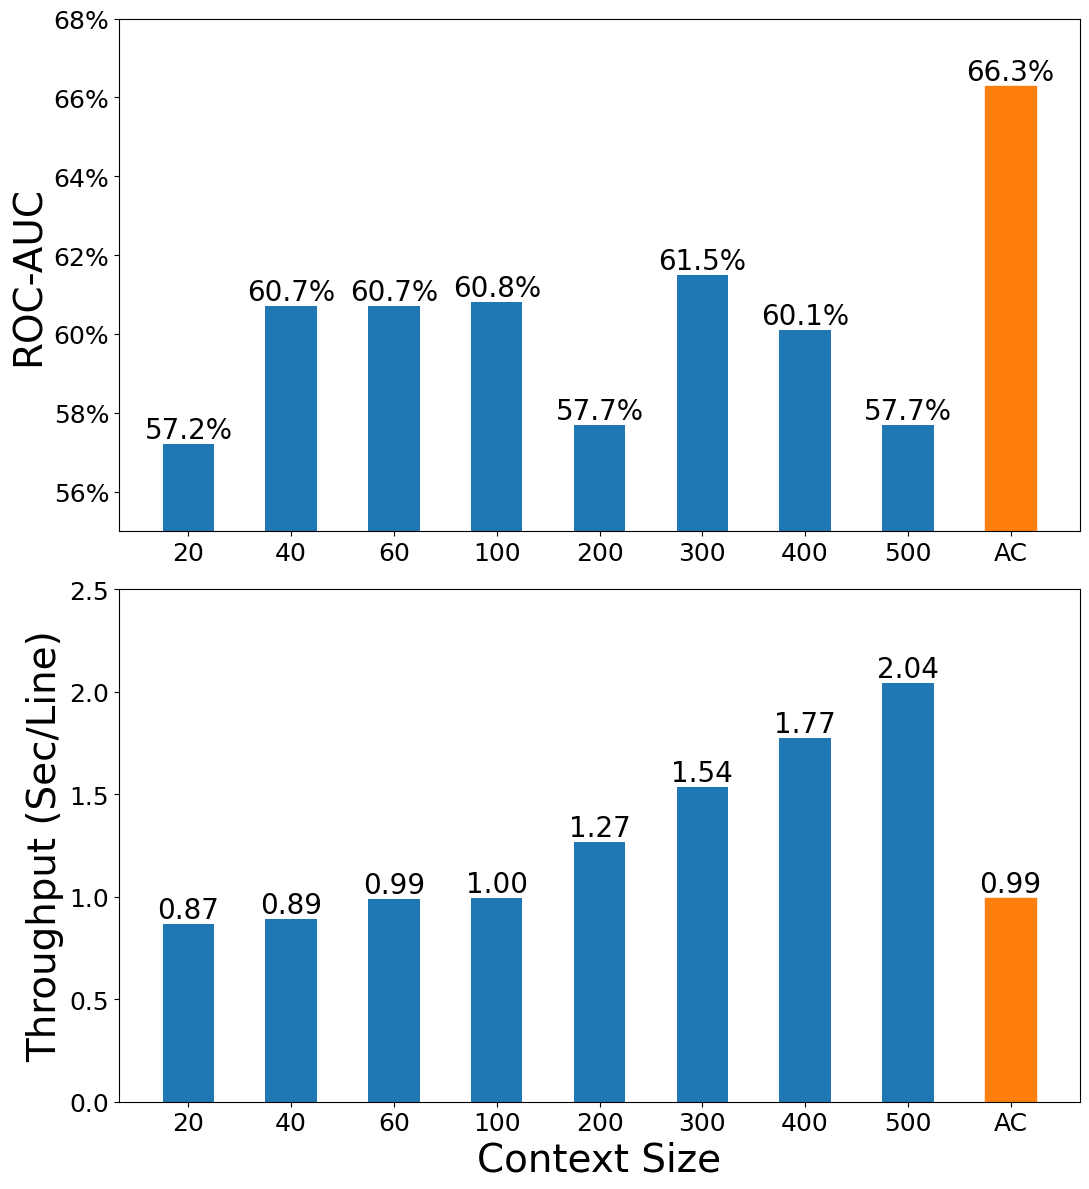

In [10]:

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(11,12))
barlist = axes[0].bar([100, 200, 300, 400, 500, 600, 700, 800, 900], 
         [57.2, 60.7, 60.7, 60.8, 57.7, 61.5, 60.1, 57.7, 66.3],
         width = 50)
barlist[-1].set_color('tab:orange')
axes[0].tick_params(axis='both', which='major', labelsize=18)
xticks = ['20', '40', '60', '100', '200', '300', '400', '500', 'AC']
axes[0].set_xticks([i for i in range(100, 1000, 100)])
axes[0].set_xticklabels(xticks)
axes[0].yaxis.set_major_locator(ticker.LogLocator(10, "auto"))
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
axes[0].set_ylabel('ROC-AUC', fontsize=28)
axes[0].bar_label(axes[0].containers[0], fontsize=20, fmt='%.1f%%')
axes[0].set_ylim(55, 68)
fig.tight_layout()

barlist = axes[1].bar([100, 200, 300, 400, 500, 600, 700, 800, 900], 
         [1802 / (2064 / 858) / 865, 1858 / (2064 / 858) / 865, 2056 / (2064 / 858) / 865, 2072 / (2064 / 858) / 865, 2636 / (2064 / 858) / 865, 3196 / (2064 / 858) / 865, 3692 / (2064 / 858) / 865, 4254 / (2064 / 858) / 865, 2064 / (2064 / 858) / 865],
         width = 50)
barlist[-1].set_color('tab:orange')
axes[1].tick_params(axis='both', which='major', labelsize=18)
xticks = ['20', '40', '60', '100', '200', '300', '400', '500', 'AC']
axes[1].set_xticks([i for i in range(100, 1000, 100)])
axes[1].set_xticklabels(xticks)
axes[1].set_xlabel('Context Size', fontsize=28)
axes[1].set_ylabel('Throughput (Sec/Line)', fontsize=28)
axes[1].bar_label(axes[1].containers[0], fontsize=20, fmt='%.2f')
axes[1].set_ylim(axes[1].get_ylim()[0], 2.5)
fig.tight_layout()

plt.show()

ROC-AUC for 1: 0.5692596435546875
ROC-AUC for 5: 0.578094482421875
ROC-AUC for 10: 0.572113037109375
ROC-AUC for 20: 0.6072540283203125
ROC-AUC for 30: 0.6070098876953125
ROC-AUC for 50: 0.6079254150390625
ROC-AUC for 100: 0.5765380859375
ROC-AUC for 150: 0.6152801513671875
ROC-AUC for 200: 0.6011810302734375
ROC-AUC for 250: 0.577362060546875
ROC-AUC for mcs: 0.6626849315068494


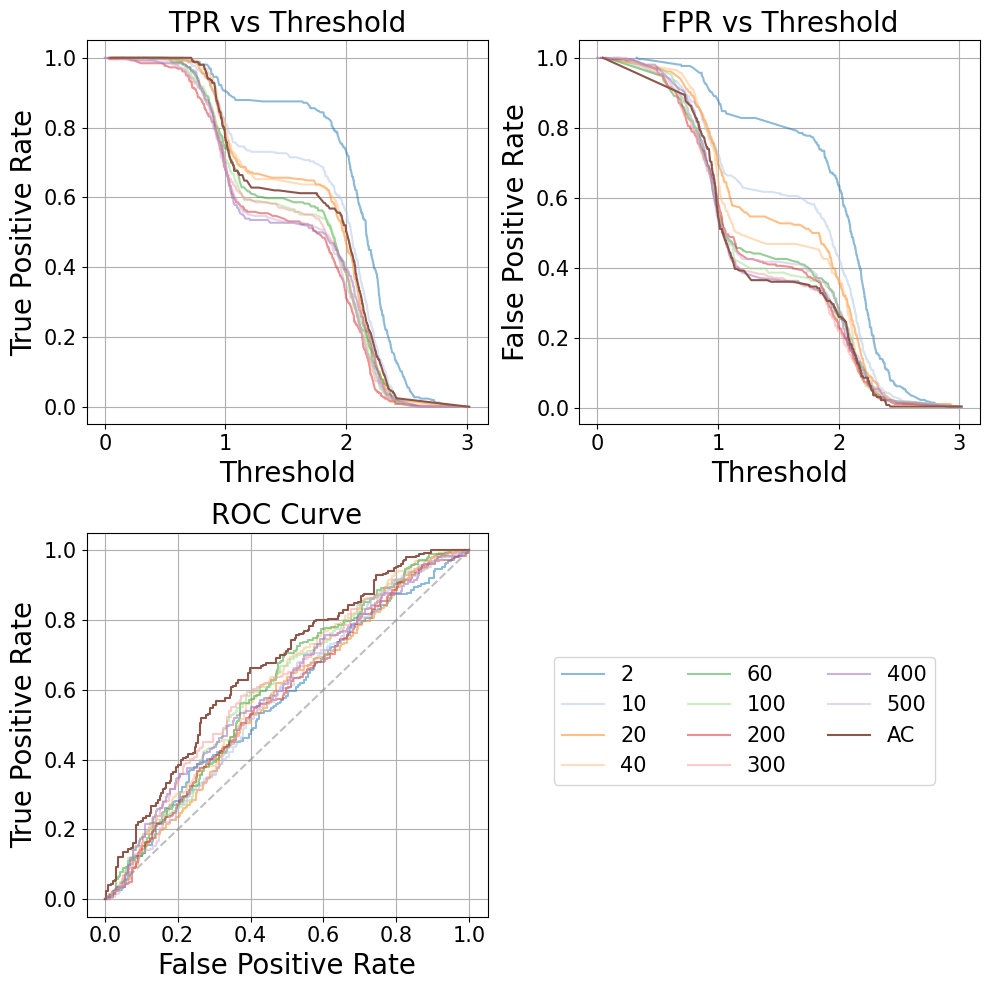

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
colors = plt.cm.tab20.colors
for id, cntx in enumerate([1, 5, 10, 20, 30, 50, 100, 150, 200, 250, "mcs"]):
    df = pd.read_csv(f"../../result/RQ_Anomaly_Score/context_len_{cntx}.csv")
    print(f"ROC-AUC for {cntx}: {sklearn.metrics.roc_auc_score(df.vul_label, df.new_score)}")
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(df['vul_label'], df['new_score'])
    axes[1][0].plot(fpr, tpr, label=f"{cntx*2 if isinstance(cntx, int) else 'AC'}", alpha=(0.5 if isinstance(cntx, int) else 1.0), color=colors[id])
    axes[0][0].plot(thresholds, tpr, label=f"{cntx*2 if isinstance(cntx, int) else 'AC'}", alpha=(0.5 if isinstance(cntx, int) else 1.0), color=colors[id])
    axes[0][1].plot(thresholds, fpr, label=f"{cntx*2 if isinstance(cntx, int) else 'AC'}", alpha=(0.5 if isinstance(cntx, int) else 1.0), color=colors[id])
axes[1][0].plot([0, 1], [0, 1], linestyle='--', color='grey', alpha=0.5)  # Diagonal line for random classifier
axes[1][0].set_xlabel("False Positive Rate", fontsize=20)
axes[1][0].set_ylabel("True Positive Rate", fontsize=20)
axes[1][0].set_title("ROC Curve", fontsize=20)
axes[1][0].tick_params(axis='both', which='major', labelsize=15)
axes[0][0].set_xlabel("Threshold", fontsize=20)
axes[0][0].set_ylabel("True Positive Rate", fontsize=20)
axes[0][0].set_title("TPR vs Threshold", fontsize=20)
axes[0][0].tick_params(axis='both', which='major', labelsize=15)
axes[0][1].set_xlabel("Threshold", fontsize=20)
axes[0][1].set_ylabel("False Positive Rate", fontsize=20)
axes[0][1].set_title("FPR vs Threshold", fontsize=20)
axes[0][1].tick_params(axis='both', which='major', labelsize=15)
axes[1][0].grid()
axes[0][0].grid()
axes[0][1].grid()
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=15, loc='lower right', ncols=3, bbox_to_anchor=(0.95, 0.2))
axes[1][1].axis('off')  # Hide the unused subplot
plt.tight_layout()
